# MNIST 데이터 로딩

이 노트북은 로컬 `.gz` 파일에서 MNIST 이미지와 레이블을 로딩하는 `load_mnist` 함수를 직접 실행하고 검증하는 실습 자료이다.
이전 노트북의 변수나 실행 결과를 사용하지 않으며, 이 노트북 단독으로 완전히 실행할 수 있다.

**실행 환경**: `conda run -n numpy_py311` (GPU 불필요)

**데이터셋 경로**: `/mnt/d/datasets/mnist/` (train/test `.gz` 4개 파일 필요)

**목표**
- `load_mnist('train')`과 `load_mnist('test')`로 이미지·레이블 배열을 로딩하고 shape와 dtype을 확인한다.
- 이미지 픽셀 분포(histogram)와 샘플 16장 grid를 시각화한다.
- 레이블 클래스 분포와 첫 번째 샘플의 원본 픽셀 값을 확인한다.

## 0. 환경 설정

In [1]:
# sys.path setup -- excluded from jupyter book build
import os
import sys

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"project_root={PROJECT_ROOT}")

project_root=/mnt/d/projects/nampluskr/10_active/260615_mnist-numpy-from-scratch


In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from src.data.mnist import load_mnist

## 1. 개요

`load_mnist`는 로컬에 저장된 4개의 MNIST `.gz` 파일을 파싱하여 이미지와 레이블 원본 배열을 반환한다.
다운로드 기능은 제공하지 않으며, 지정된 경로(`/mnt/d/datasets/mnist/`)에 파일이 있어야 동작한다.

반환 배열의 형태와 타입은 다음과 같다.

| 반환값 | shape | dtype | 설명 |
|---|---|---|---|
| `images` | `(N, 28, 28)` | `uint8` | 픽셀 값 0~255 원본 |
| `labels` | `(N,)` | `uint8` | 클래스 번호 0~9 |

train split은 60,000장, test split은 10,000장이다.

## 2. 데이터 로딩 및 shape 확인

`load_mnist`에 `split='train'` 또는 `split='test'`를 전달하여 이미지와 레이블을 로딩한다.
반환되는 배열의 shape, dtype, 픽셀 값 범위를 확인한다.

In [4]:
train_images, train_labels = load_mnist('train')
test_images, test_labels = load_mnist('test')

print("[train]")
print(f"  images: shape={train_images.shape}, dtype={train_images.dtype}")
print(f"  labels: shape={train_labels.shape}, dtype={train_labels.dtype}")
print(f"  pixel range: min={train_images.min()}, max={train_images.max()}")

print("[test]")
print(f"  images: shape={test_images.shape}, dtype={test_images.dtype}")
print(f"  labels: shape={test_labels.shape}, dtype={test_labels.dtype}")

[train]
  images: shape=(60000, 28, 28), dtype=uint8
  labels: shape=(60000,), dtype=uint8
  pixel range: min=0, max=255
[test]
  images: shape=(10000, 28, 28), dtype=uint8
  labels: shape=(10000,), dtype=uint8


In [5]:
assert train_images.shape == (60000, 28, 28), f"expected (60000,28,28), got {train_images.shape}"
assert train_labels.shape == (60000,), f"expected (60000,), got {train_labels.shape}"
assert test_images.shape == (10000, 28, 28), f"expected (10000,28,28), got {test_images.shape}"
assert test_labels.shape == (10000,), f"expected (10000,), got {test_labels.shape}"
assert train_images.dtype == np.uint8, f"expected uint8, got {train_images.dtype}"
assert train_labels.dtype == np.uint8, f"expected uint8, got {train_labels.dtype}"
assert train_images.min() == 0 and train_images.max() == 255, "pixel range mismatch"

print("load_mnist shape/dtype validation passed")

load_mnist shape/dtype validation passed


## 3. 샘플 이미지 시각화

train split에서 앞 16장의 이미지를 4×4 grid로 시각화한다.
각 이미지 아래에 정수 레이블(0~9)을 표시하여 손글씨 숫자 형태를 확인한다.

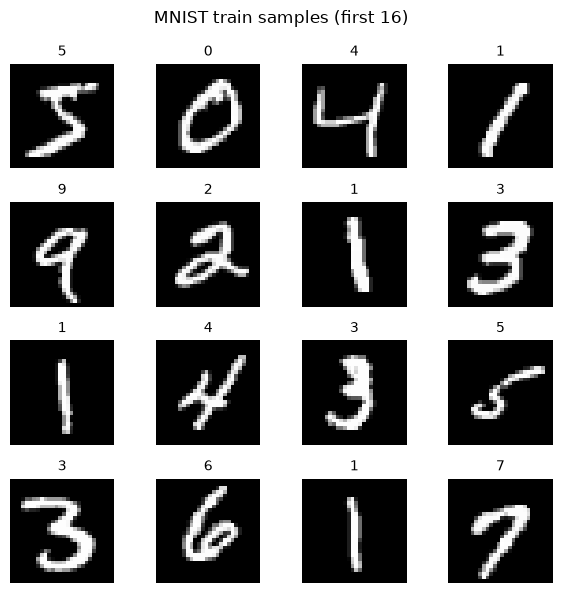

In [6]:
fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(train_images[i], cmap='gray', vmin=0, vmax=255)
    ax.set_title(str(train_labels[i]), fontsize=10)
    ax.axis('off')
fig.suptitle("MNIST train samples (first 16)", fontsize=12)
fig.tight_layout()
plt.show()

## 4. 픽셀 분포 및 레이블 분포

train 이미지 전체의 픽셀 값 분포(histogram)와 레이블 클래스별 샘플 수를 시각화한다.
픽셀 histogram은 배경(0)이 압도적으로 많고 나머지 픽셀은 넓게 분포하는 양상을 확인할 수 있다.
레이블 분포는 10개 클래스가 비교적 균등하게 분포하는지 확인한다.

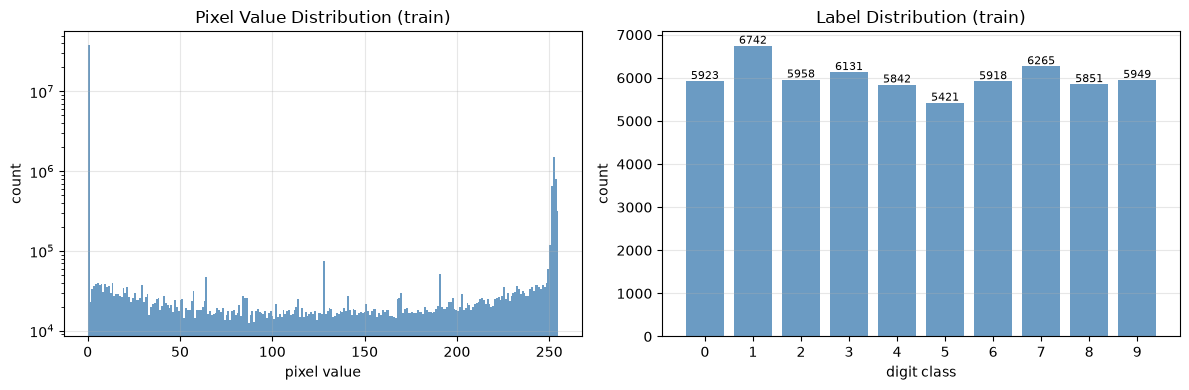

label counts: [5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]
min=5421, max=6742, ratio=1.24


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# pixel histogram (exclude 0 to see non-background distribution)
pixels = train_images.ravel()
axes[0].hist(pixels, bins=256, range=(0, 255), color='steelblue', alpha=0.8)
axes[0].set_title("Pixel Value Distribution (train)")
axes[0].set_xlabel("pixel value")
axes[0].set_ylabel("count")
axes[0].set_yscale('log')
axes[0].grid(alpha=0.3)

# label class distribution
counts = np.bincount(train_labels, minlength=10)
axes[1].bar(range(10), counts, color='steelblue', alpha=0.8)
axes[1].set_title("Label Distribution (train)")
axes[1].set_xlabel("digit class")
axes[1].set_ylabel("count")
axes[1].set_xticks(range(10))
axes[1].grid(axis='y', alpha=0.3)
for i, c in enumerate(counts):
    axes[1].text(i, c + 50, str(c), ha='center', fontsize=8)

fig.tight_layout()
plt.show()

print(f"label counts: {counts}")
print(f"min={counts.min()}, max={counts.max()}, ratio={counts.max()/counts.min():.2f}")

## 5. 단일 샘플 상세 확인

첫 번째 train 샘플의 이미지와 픽셀 값을 함께 표시한다.
28×28 픽셀 grid에서 숫자가 어느 영역을 차지하는지, 배경(0)과 전경(비零)이 어떻게 분포하는지 직접 확인한다.

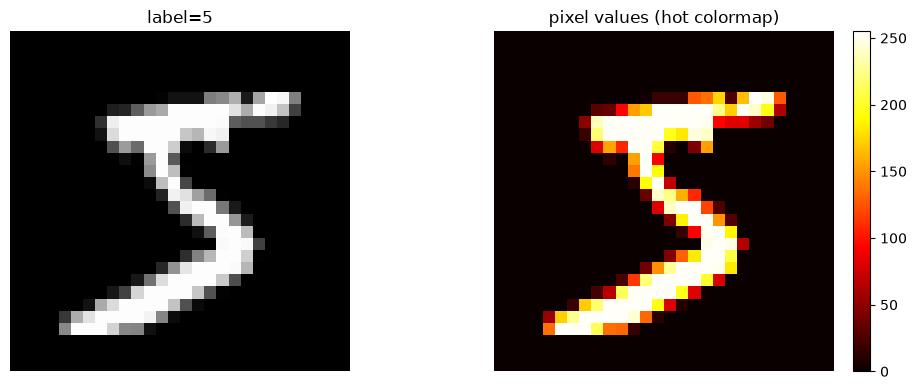

sample[0]: label=5, non-zero pixels=166/784, mean=35.1, std=79.6


In [8]:
idx = 0
img = train_images[idx]  # shape (28, 28), dtype uint8
lbl = train_labels[idx]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# image visualization
axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0].set_title(f"label={lbl}")
axes[0].axis('off')

# pixel value heatmap
im = axes[1].imshow(img, cmap='hot', vmin=0, vmax=255)
axes[1].set_title("pixel values (hot colormap)")
axes[1].axis('off')
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

fig.tight_layout()
plt.show()

non_zero = np.count_nonzero(img)
print(f"sample[{idx}]: label={lbl}, non-zero pixels={non_zero}/{28*28}, "
      f"mean={img.mean():.1f}, std={img.std():.1f}")

In [9]:
assert img.shape == (28, 28), f"expected (28,28), got {img.shape}"
assert img.dtype == np.uint8, f"expected uint8, got {img.dtype}"
assert 0 <= int(lbl) <= 9, f"label out of range: {lbl}"

print("single sample validation passed")

single sample validation passed


## 요약

이 노트북에서 확인한 내용은 다음과 같다.

| 항목 | 내용 |
|---|---|
| `load_mnist('train')` | images `(60000, 28, 28)` uint8, labels `(60000,)` uint8 |
| `load_mnist('test')` | images `(10000, 28, 28)` uint8, labels `(10000,)` uint8 |
| 픽셀 값 범위 | 0~255 (배경=0, 전경=1~255) |
| 레이블 범위 | 정수 0~9, 10개 클래스 |
| 클래스 분포 | 최소~최대 약 5,421~6,742장으로 비교적 균등 |

**핵심 설계 원칙**
- `load_mnist`는 원본 uint8 배열을 그대로 반환한다. 정규화·reshape·target 변환은 `MNISTDataset`이 담당한다.
- split은 `'train'`과 `'test'` 두 값만 허용하며, 그 외 값은 `ValueError`를 발생시킨다.